# Advanced Mutual Fund Analytics
This notebook covers tail-risk assessment, rolling performance metrics, investor behavior analysis, and portfolio concentration metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Robust pathing logic
BASE_DIR = Path.cwd()
if BASE_DIR.name == 'notebooks':
    PROCESSED_DATA_DIR = BASE_DIR.parent / 'data' / 'processed'
else:
    PROCESSED_DATA_DIR = BASE_DIR / 'data' / 'processed'

def load_data(file_name):
    file_path = PROCESSED_DATA_DIR / file_name
    if not file_path.exists():
        raise FileNotFoundError(f"Could not find {file_path}. Ensure ETL is run.")
    return pd.read_csv(file_path)

# Load datasets
df_nav = load_data('fact_nav.csv')
df_tx = load_data('fact_transactions.csv')
df_holdings = load_data('09_portfolio_holdings.csv')
df_funds = load_data('dim_fund.csv')
df_scorecard = load_data('fund_scorecard.csv')

# Pre-processing
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_tx['transaction_date'] = pd.to_datetime(df_tx['transaction_date'])

print("Advanced data loaded successfully.")

Advanced data loaded successfully.


## 1. Tail Risk Assessment: Historical VaR & CVaR
Calculating 95% Value-at-Risk and Conditional VaR (Expected Shortfall) to understand extreme downside risk.

C:\Users\gvsp1\AppData\Local\Temp\ipykernel_13712\404051510.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tail_risk.head(10), x='CVaR_95', y='scheme_name', palette='Reds_r')


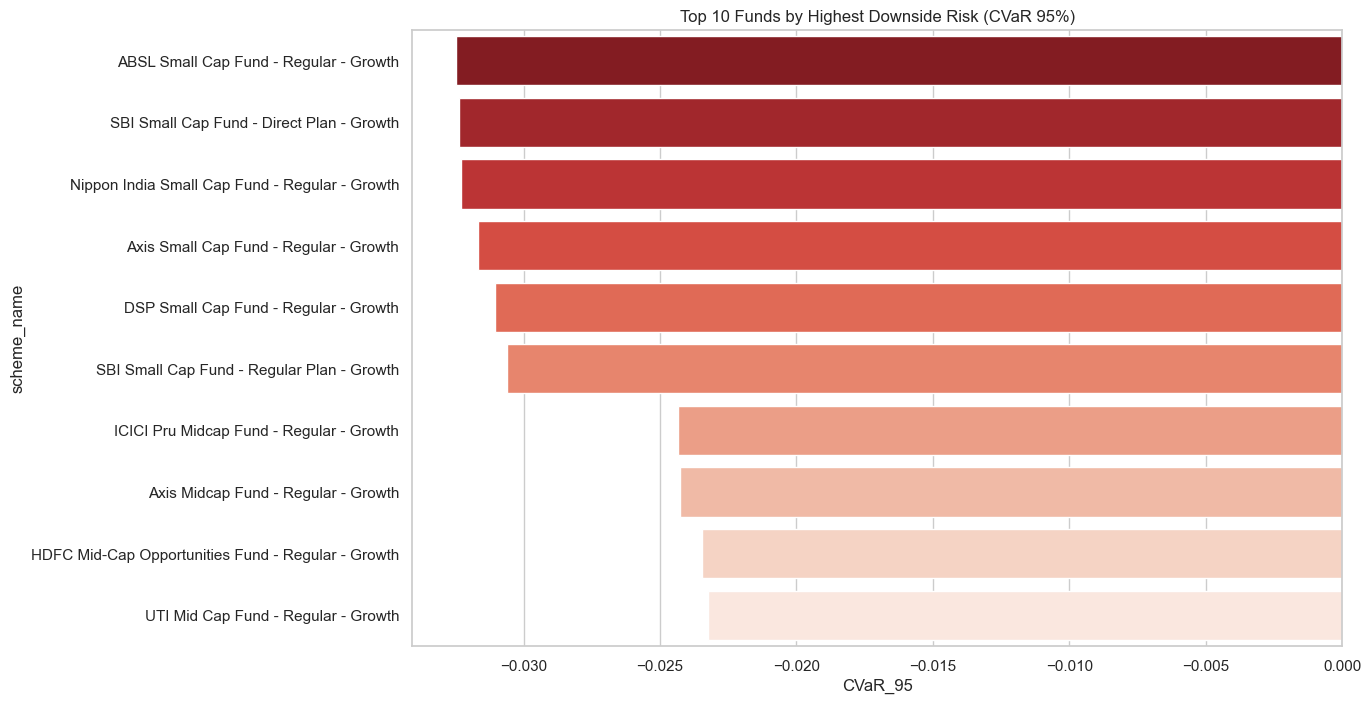

In [2]:
tail_risk = []
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

for amfi_code in df_nav['amfi_code'].unique():
    returns = df_nav[df_nav['amfi_code'] == amfi_code]['daily_return'].dropna()
    if len(returns) < 100: continue
    
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    
    tail_risk.append({
        'amfi_code': amfi_code,
        'VaR_95': var_95,
        'CVaR_95': cvar_95
    })

df_tail_risk = pd.DataFrame(tail_risk).merge(df_funds[['amfi_code', 'scheme_name']], on='amfi_code')
df_tail_risk = df_tail_risk.sort_values('CVaR_95')

plt.figure(figsize=(12, 8))
sns.barplot(data=df_tail_risk.head(10), x='CVaR_95', y='scheme_name', palette='Reds_r')
plt.title('Top 10 Funds by Highest Downside Risk (CVaR 95%)')
plt.show()

## 2. Rolling 90-Day Sharpe Ratio
Tracking how risk-adjusted performance changes over time for the top 5 funds.

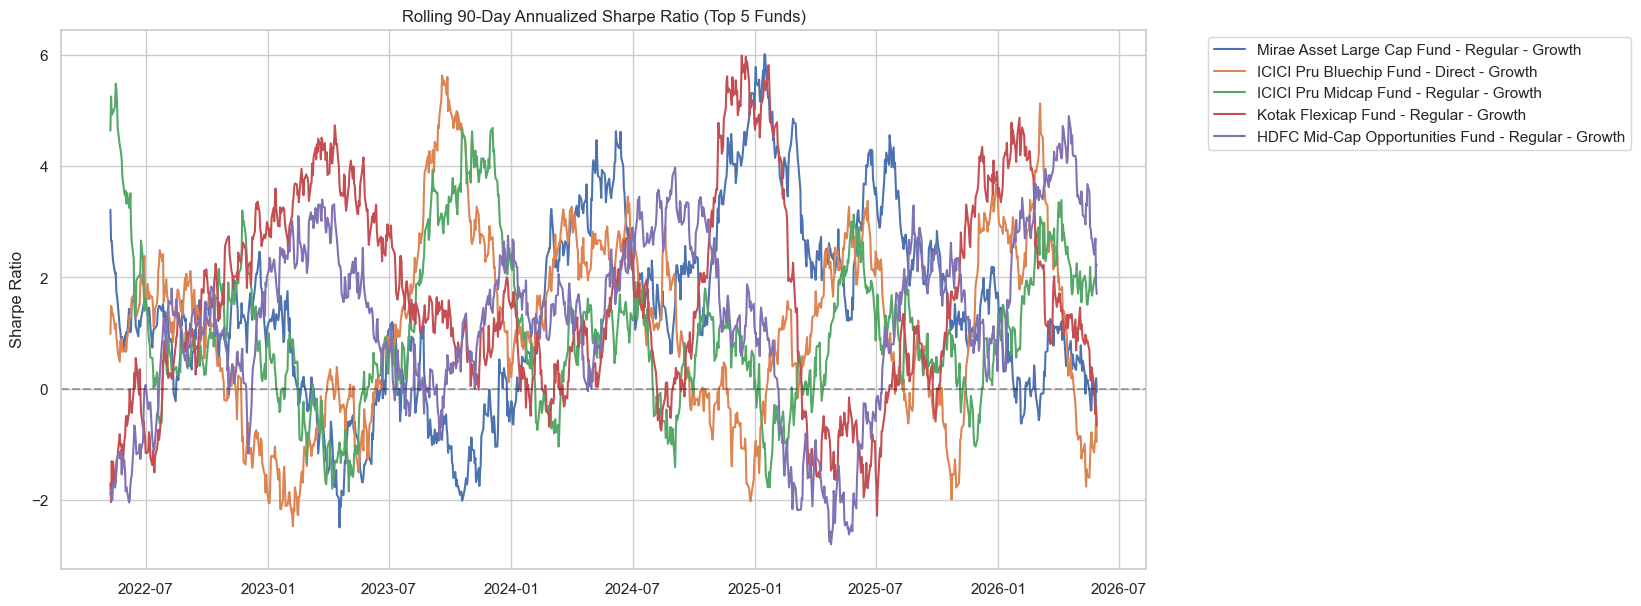

In [3]:
top_5_amfi = df_scorecard.head(5)['amfi_code'].tolist()
rf_daily = (1.065)**(1/252) - 1

plt.figure(figsize=(14, 7))

for amfi_code in top_5_amfi:
    fund_name = df_funds[df_funds['amfi_code'] == amfi_code]['scheme_name'].values[0]
    subset = df_nav[df_nav['amfi_code'] == amfi_code].set_index('date').sort_index()
    
    # Rolling window stats
    rolling = subset['daily_return'].rolling(window=90)
    rolling_sharpe = (rolling.mean() - rf_daily) / rolling.std() * np.sqrt(252)
    
    plt.plot(rolling_sharpe.index, rolling_sharpe, label=fund_name)

plt.title('Rolling 90-Day Annualized Sharpe Ratio (Top 5 Funds)')
plt.ylabel('Sharpe Ratio')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 3. Investor Cohort Analysis
Grouping investors by their entry year to see long-term retention and ticket size.

In [4]:
# Find first transaction date for each investor
investor_first_tx = df_tx.groupby('investor_id')['transaction_date'].min().reset_index()
investor_first_tx['cohort_year'] = investor_first_tx['transaction_date'].dt.year

# Merge back to main transactions
df_cohorts = df_tx.merge(investor_first_tx[['investor_id', 'cohort_year']], on='investor_id')

# Analyze average investment by cohort over time
cohort_stats = df_cohorts.groupby('cohort_year').agg({
    'investor_id': 'nunique',
    'amount_inr': ['sum', 'mean']
}).reset_index()
cohort_stats.columns = ['Cohort Year', 'Unique Investors', 'Total Invested', 'Avg Ticket Size']

fig = px.bar(cohort_stats, x='Cohort Year', y='Unique Investors', text='Avg Ticket Size', 
             title='Investor Cohorts by Entry Year',
             labels={'Unique Investors': 'Number of Investors'})
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.show()

## 4. SIP Continuity Analysis
Identifying 'leaky' SIPs by flagging investors who missed a cycle (gap > 35 days).

Total SIP Investors: 4762
Investors with >35 day gap: 3906 (82.0%)


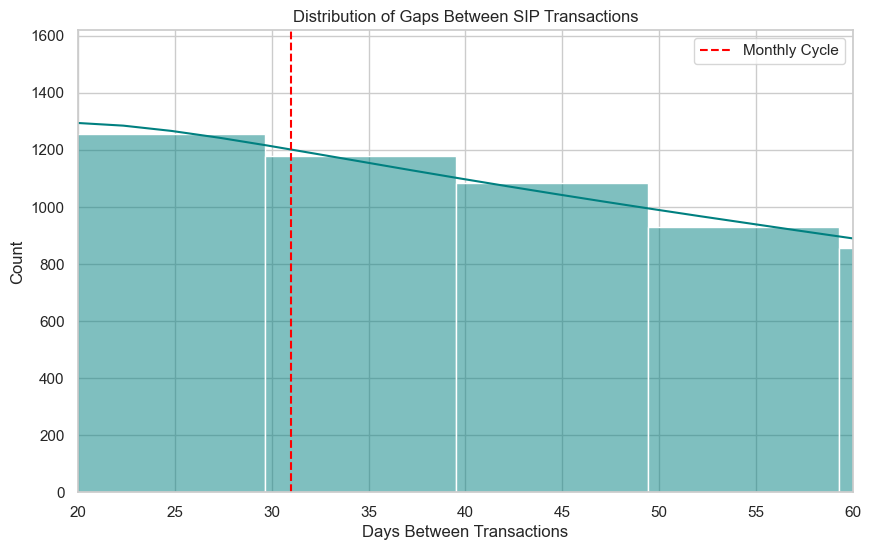

In [5]:
df_sip = df_tx[df_tx['transaction_type'] == 'SIP'].sort_values(['investor_id', 'transaction_date'])
df_sip['prev_date'] = df_sip.groupby('investor_id')['transaction_date'].shift(1)
df_sip['gap_days'] = (df_sip['transaction_date'] - df_sip['prev_date']).dt.days

lapsed_sips = df_sip[df_sip['gap_days'] > 35]
num_lapsed = lapsed_sips['investor_id'].nunique()
total_sip_investors = df_sip['investor_id'].nunique()

print(f"Total SIP Investors: {total_sip_investors}")
print(f"Investors with >35 day gap: {num_lapsed} ({num_lapsed/total_sip_investors:.1%})")

# Visualize gap distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_sip['gap_days'].dropna(), bins=50, kde=True, color='teal')
plt.axvline(31, color='red', linestyle='--', label='Monthly Cycle')
plt.title('Distribution of Gaps Between SIP Transactions')
plt.xlabel('Days Between Transactions')
plt.legend()
plt.xlim(20, 60)
plt.show()

## 5. Fund Recommender
Simple recommendation logic based on user risk appetite.

In [6]:
def recommend_funds(risk_level, top_n=3):
    risk_map = {
        'Low': ['Low', 'Low to Moderate'],
        'Moderate': ['Moderate', 'Moderately High'],
        'High': ['High', 'Very High']
    }
    
    allowed_grades = risk_map.get(risk_level, ['Moderate'])
    
    # Merge scorecard with fund details for risk grades
    recommendations = df_scorecard.merge(df_funds[['amfi_code', 'risk_category']], on='amfi_code')
    
    # Filter and sort
    filtered = recommendations[recommendations['risk_category'].isin(allowed_grades)]
    
    return filtered[['scheme_name', 'risk_category', 'composite_score', 'cagr_3yr']].head(top_n)

print("Recommendations for 'High' Risk Appetite:")
display(recommend_funds('High'))

print("\nRecommendations for 'Low' Risk Appetite:")
display(recommend_funds('Low'))

Recommendations for 'High' Risk Appetite:


,scheme_name,risk_category,composite_score,cagr_3yr
2,ICICI Pru Midcap Fund - Regular - Growth,High,78.899019,0.315179
4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High,76.993150,0.324469
5,Axis Midcap Fund - Regular - Growth,High,75.842068,0.353344



Recommendations for 'Low' Risk Appetite:


,scheme_name,risk_category,composite_score,cagr_3yr
19,ICICI Pru Liquid Fund - Regular - Growth,Low,55.038913,0.073848
25,Kotak Liquid Fund - Regular - Growth,Low,48.722139,0.067025
29,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,38.356548,0.059138


## 6. Portfolio Concentration (Sector HHI)
Calculating the Herfindahl-Hirschman Index (HHI) to measure sector diversification.

Top 5 Concentrated Funds (High HHI):


,amfi_code,sector_hhi,scheme_name
11,119092,2967.6909,Axis Bluechip Fund - Regular - Growth
30,148569,2549.9194,Mirae Asset Tax Saver Fund - Regular - Growth
27,125498,2531.5500,HDFC Mid-Cap Opportunities Fund - Direct - Growth
6,102887,2513.8255,UTI Flexi Cap Fund - Regular - Growth
32,149323,2410.7664,DSP Midcap Fund - Regular - Growth



Top 5 Well-Diversified Funds (Low HHI):


,amfi_code,sector_hhi,scheme_name
9,118634,1602.9924,Nippon India Small Cap Fund - Regular - Growth
14,119095,1595.8229,Axis Small Cap Fund - Regular - Growth
15,119551,1424.9104,SBI Bluechip Fund - Regular Plan - Growth
25,120843,1362.0616,Kotak Flexicap Fund - Regular - Growth
5,102886,1240.2024,UTI Mid Cap Fund - Regular - Growth


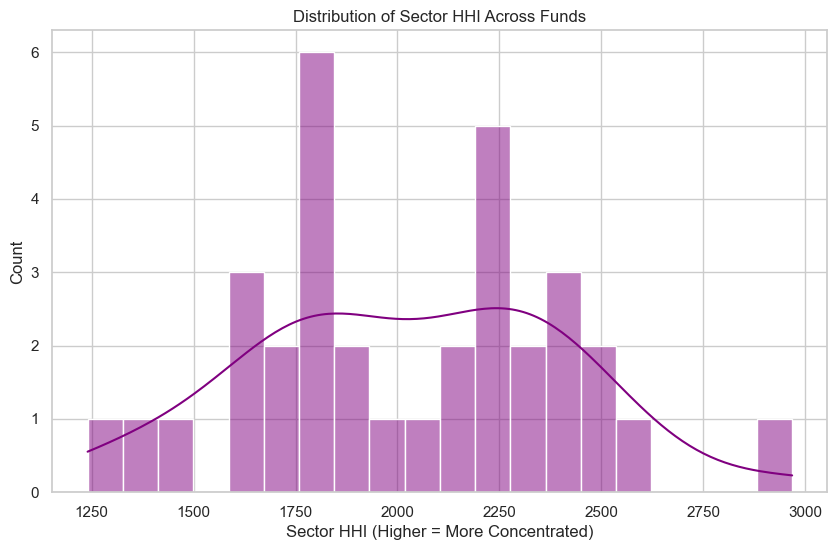

In [7]:
# Group by fund and sector, sum weights
sector_weights = df_holdings.groupby(['amfi_code', 'sector'])['weight_pct'].sum().reset_index()

# HHI = Sum of squares of sector weights
sector_weights['weight_sq'] = sector_weights['weight_pct'] ** 2
hhi_stats = sector_weights.groupby('amfi_code')['weight_sq'].sum().reset_index()
hhi_stats.columns = ['amfi_code', 'sector_hhi']

# Merge with fund names
df_hhi = hhi_stats.merge(df_funds[['amfi_code', 'scheme_name']], on='amfi_code')
df_hhi = df_hhi.sort_values('sector_hhi', ascending=False)

print("Top 5 Concentrated Funds (High HHI):")
display(df_hhi.head(5))

print("\nTop 5 Well-Diversified Funds (Low HHI):")
display(df_hhi.tail(5))

plt.figure(figsize=(10, 6))
sns.histplot(df_hhi['sector_hhi'], bins=20, color='purple', kde=True)
plt.title('Distribution of Sector HHI Across Funds')
plt.xlabel('Sector HHI (Higher = More Concentrated)')
plt.show()

In [ ]:
var_cvar_df = df_tail_risk
var_cvar_df.to_csv('../data/processed/var_cvar_report.csv', index=False)